In [1]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
corpora = pd.read_parquet("../../corpora/GeneratedCorpus/corpora_v3.parquet")
corpora = corpora.reset_index(names='text_id')


results = pd.DataFrame()
for res in glob("./results5/*"):
    temp = pd.read_csv(res)
    results = pd.concat([results, temp])


df = pd.merge(results, corpora)

# df = df[~df["scenario"].isin(["GRAMMAR SWAP", "GRAMMAR SWAP v2"])]
df = df[df["language"].isin(["INGLÊS", "PB NATIVO"])]
df = df[~df["model"].isin(["Qwen3.5-9B-it", "Tucano-2b4-it", "Gemma4-12B-it"])]

In [3]:
df

,text_id,num_words,num_bytes,num_tokens,tokens_per_word,average_nll,total_nll,ppl,bpb,model,scenario,language,task,task_type,text
0,0,153,999,241,1.58,2.80,672.95,16.51,0.97,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,"Fondant / Pasta de goma Ei todos, boa noite! E..."
1,1,173,1103,245,1.42,2.79,681.10,16.30,0.89,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,"Querido Sr. Ministro, Como eu escrevo isso, eu..."
2,2,156,945,215,1.38,3.18,681.45,24.15,1.04,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,Tens notado como diferentes teus pais têm sido...
3,3,169,1018,238,1.41,3.17,750.62,23.74,1.06,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,Uma Carta Aberta Na página 2 da Folha de S.Pau...
4,4,173,1070,230,1.33,3.27,749.17,26.35,1.01,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,Carta Aberta Nazismo revelou a face mais escur...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10485,1675,314,1968,510,1.62,3.20,1627.96,24.49,1.19,Cabrita,GRAMMAR SWAP v3,INGLÊS,EXPLORAR,FD,"INTERLOCUTOR1: Oh, eu acho que não o CD desapa..."
10486,1676,314,1836,453,1.44,3.26,1472.91,26.01,1.16,Cabrita,GRAMMAR SWAP v3,INGLÊS,EXPLORAR,FD,MEDIADOR: Nós vamos dar a palavra a aqui aos n...
10487,1677,342,1990,480,1.40,3.84,1836.99,46.30,1.33,Cabrita,GRAMMAR SWAP v3,INGLÊS,EXPLORAR,FD,"Sim, o fato é que muitos mitos sobre a origem ..."
10488,1678,262,1728,399,1.52,3.22,1280.30,24.95,1.07,Cabrita,GRAMMAR SWAP v3,INGLÊS,EXPLORAR,FD,"INTERLOCUTOR1: Doutor Interlocutor2, boa noite..."


In [4]:
gs = corpora[
    (corpora["scenario"] == "GRAMMAR SWAP") &
    (corpora["language"] == "INGLÊS")
]

gs_tasks = gs.task.unique().tolist()

# Selecionando somente os mesmos textos
gs3 = corpora[
    (corpora["scenario"] == "GRAMMAR SWAP v3") &
    (corpora["language"] == "INGLÊS") &
    (corpora["task"].isin(gs_tasks))
]

id_mapping = zip(gs["text_id"].to_list(), gs3["text_id"].to_list())

In [5]:
df_res = df[
    (df["text_id"].isin(gs["text_id"].to_list())) | 
    (df["text_id"].isin(gs3["text_id"].to_list()))
]

In [6]:
df_res

,text_id,num_words,num_bytes,num_tokens,tokens_per_word,average_nll,total_nll,ppl,bpb,model,scenario,language,task,task_type,text
0,0,153,999,241,1.58,2.80,672.95,16.51,0.97,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,"Fondant / Pasta de goma Ei todos, boa noite! E..."
1,1,173,1103,245,1.42,2.79,681.10,16.30,0.89,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,"Querido Sr. Ministro, Como eu escrevo isso, eu..."
2,2,156,945,215,1.38,3.18,681.45,24.15,1.04,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,Tens notado como diferentes teus pais têm sido...
3,3,169,1018,238,1.41,3.17,750.62,23.74,1.06,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,Uma Carta Aberta Na página 2 da Folha de S.Pau...
4,4,173,1070,230,1.33,3.27,749.17,26.35,1.01,Gemma4-12B,GRAMMAR SWAP,INGLÊS,CAPACITAR,ED,Carta Aberta Nazismo revelou a face mais escur...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10436,1626,134,950,188,1.40,3.18,595.52,24.16,0.90,Cabrita,GRAMMAR SWAP v3,INGLÊS,EXPLICAR,ED,1 – O que é FIES? FIES é um Ministério da Educ...
10437,1627,214,1337,362,1.69,3.49,1261.24,32.91,1.36,Cabrita,GRAMMAR SWAP v3,INGLÊS,EXPLICAR,FD,"SPEAKER1 alguns erros, auditor? SPEAKER2 nas a..."
10438,1628,183,1206,269,1.47,4.25,1138.13,69.88,1.36,Cabrita,GRAMMAR SWAP v3,INGLÊS,EXPLICAR,FD,"PEDRO no segundo segmento segmento, nós ouvimo..."
10439,1629,88,476,128,1.45,4.06,515.69,58.01,1.56,Cabrita,GRAMMAR SWAP v3,INGLÊS,EXPLICAR,FD,JOÃO mas qual é sua objeção exatamente? está v...


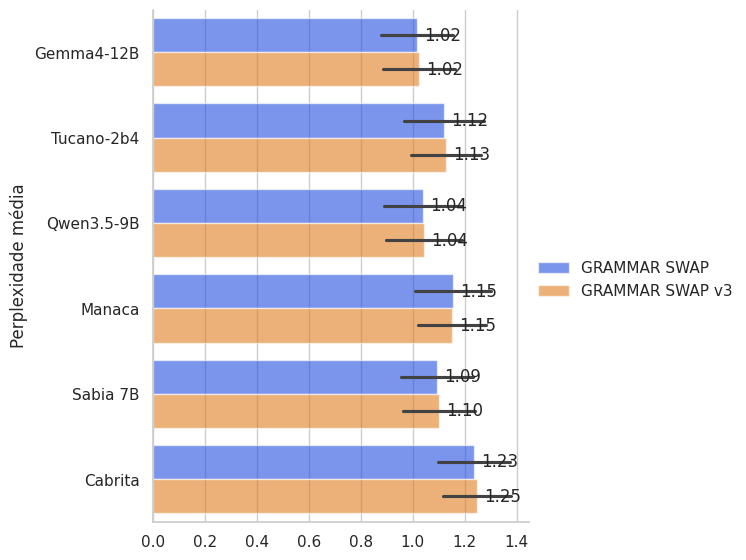

In [7]:
plot_df = df_res[
    df_res["scenario"].isin(["GRAMMAR SWAP", "GRAMMAR SWAP v3"])
].copy()

g = sns.catplot(
    data=plot_df,
    kind="bar",
    y="model", x="bpb", orient="h", 
    hue="scenario",
    estimator="mean", errorbar="sd", 
    palette="bright", alpha=.6, height=6, 
)

g.set_axis_labels("", "Perplexidade média")
g.legend.set_title("")

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=5)

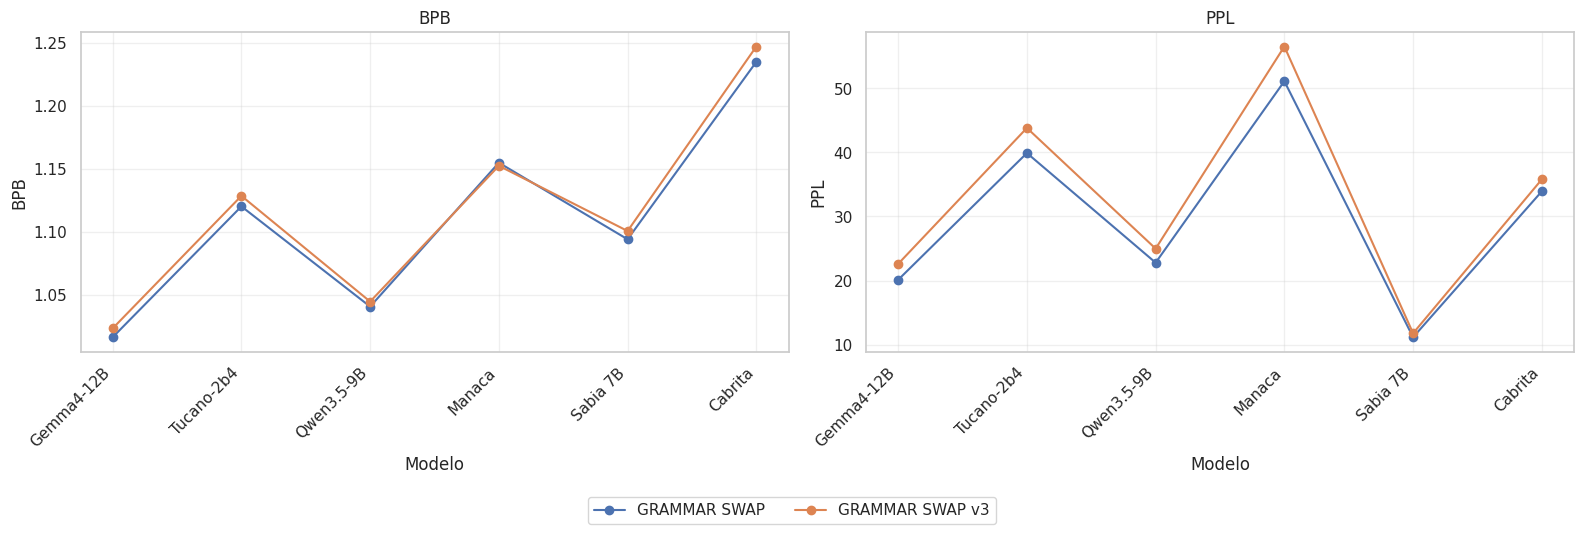

In [8]:
def plot_results(scenarios =["GRAMMAR SWAP", "GRAMMAR SWAP v3"], confidence_bands = False):

    models = df_res["model"].unique()
    x = range(len(models))

    metrics = ["bpb", "ppl"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, metric in zip(axes, metrics):

        for scenario in scenarios:
            y = []
            bands = []

            for model in models:
                value = df_res[(df_res["scenario"] == scenario) & (df_res["model"] == model)][metric]
                y.append(value.mean())
                bands.append(value.std())

            y = np.array(y)
            bands = np.array(bands)

            line, = ax.plot(x, y, marker="o", label=scenario)

            # Confidence bands
            if confidence_bands:
                ax.fill_between(x, y-bands, y+bands, alpha=0.2, color=line.get_color())

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha="right")
        ax.set_xlabel("Modelo")
        ax.set_ylabel(metric.upper())
        ax.set_title(metric.upper())
        ax.grid(alpha=0.3)


    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(scenarios),
        bbox_to_anchor=(0.5, -0.08)
    )

    plt.tight_layout()
    plt.show()

plot_results()

In [9]:
def plot_grammar_and_lexical_swap(model, plot=True):

    print(model)

    metrics = ["bpb", "ppl"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, metric in zip(axes, metrics):

        GS = df_res[(df_res["scenario"]=="GRAMMAR SWAP v3") & (df_res["model"]==model)][metric].to_list()
        LS = df_res[(df_res["scenario"]=="GRAMMAR SWAP") & (df_res["model"]==model)][metric].to_list()

        cont = 0
        for gs, ls in zip(GS, LS):
            if gs < ls:
                cont += 1

        perc = cont / len(GS) * 100
        print(f"GRAMMAR SWAP V3's {metric.upper()} < GRAMMAR SWAP in {perc:.2f}% of the times")

        x = range(len(GS))

        ax.plot(x, GS, label="GRAMMAR SWAP v3")
        ax.plot(x, LS, label="GRAMMAR SWAP")
        ax.legend()
        ax.set_title(metric.upper())

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, -0.08)
    )

    plt.tight_layout()
    plt.show()


Gemma4-12B
GRAMMAR SWAP V3's BPB < GRAMMAR SWAP in 37.50% of the times
GRAMMAR SWAP V3's PPL < GRAMMAR SWAP in 20.83% of the times


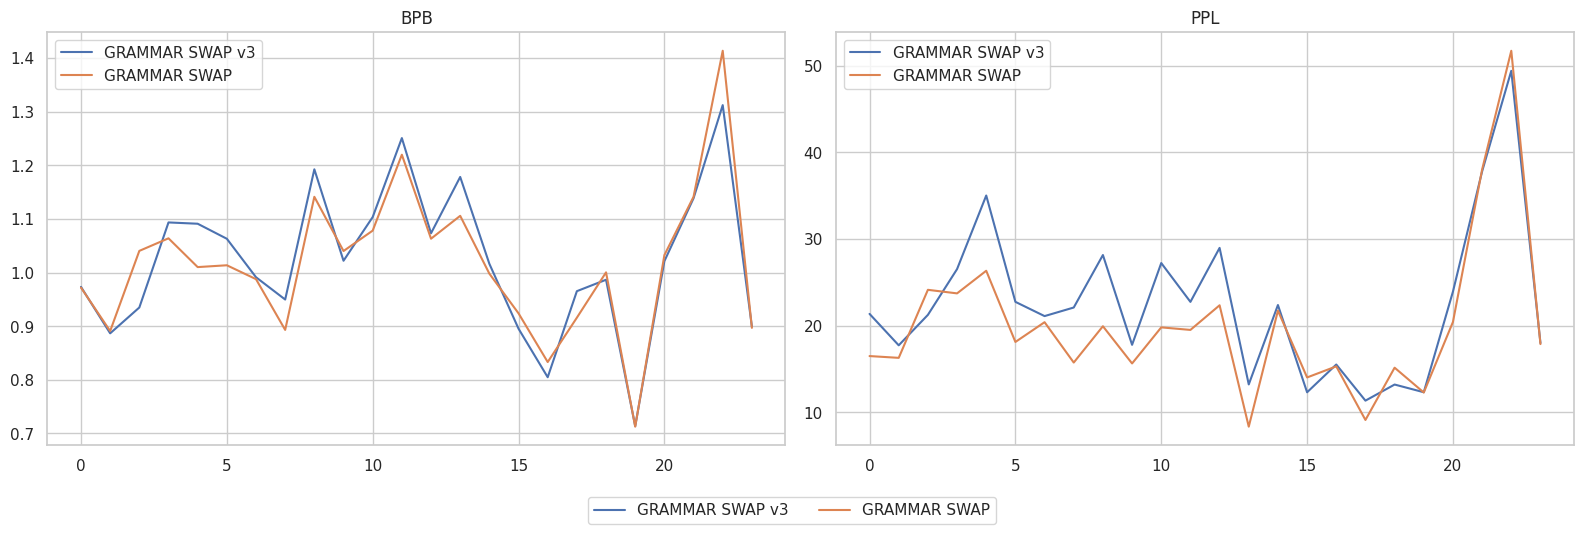

Tucano-2b4
GRAMMAR SWAP V3's BPB < GRAMMAR SWAP in 41.67% of the times
GRAMMAR SWAP V3's PPL < GRAMMAR SWAP in 33.33% of the times


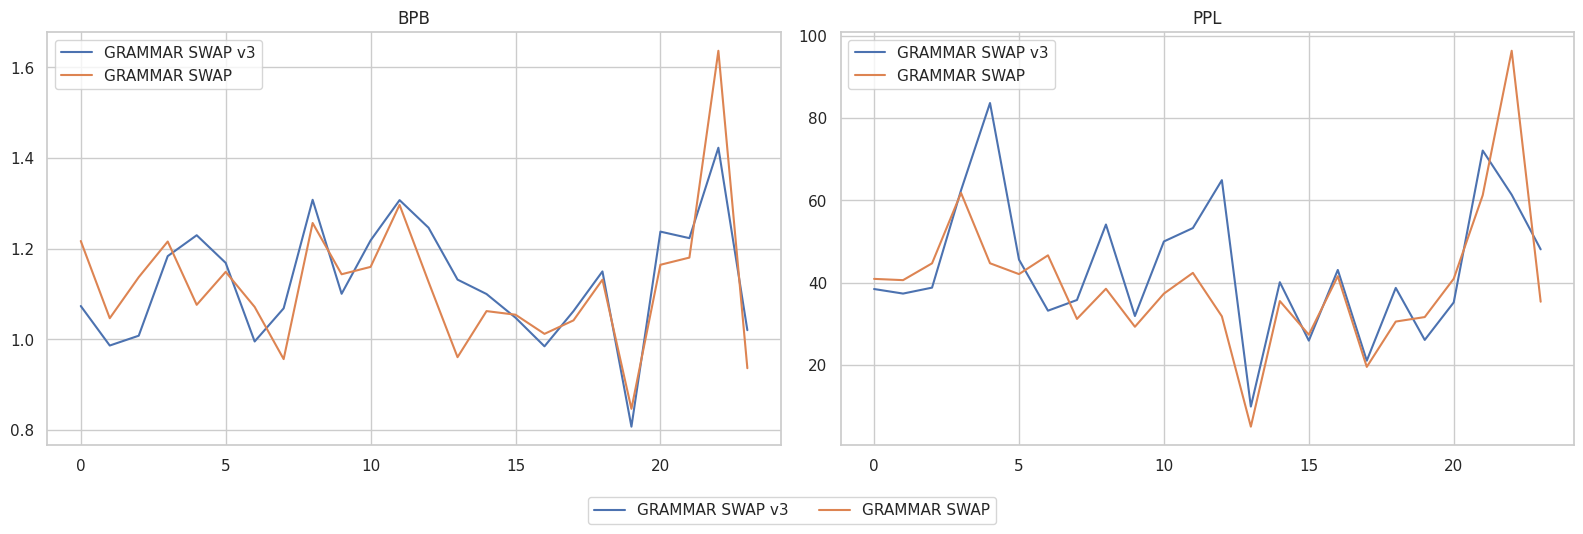

Qwen3.5-9B
GRAMMAR SWAP V3's BPB < GRAMMAR SWAP in 37.50% of the times
GRAMMAR SWAP V3's PPL < GRAMMAR SWAP in 33.33% of the times


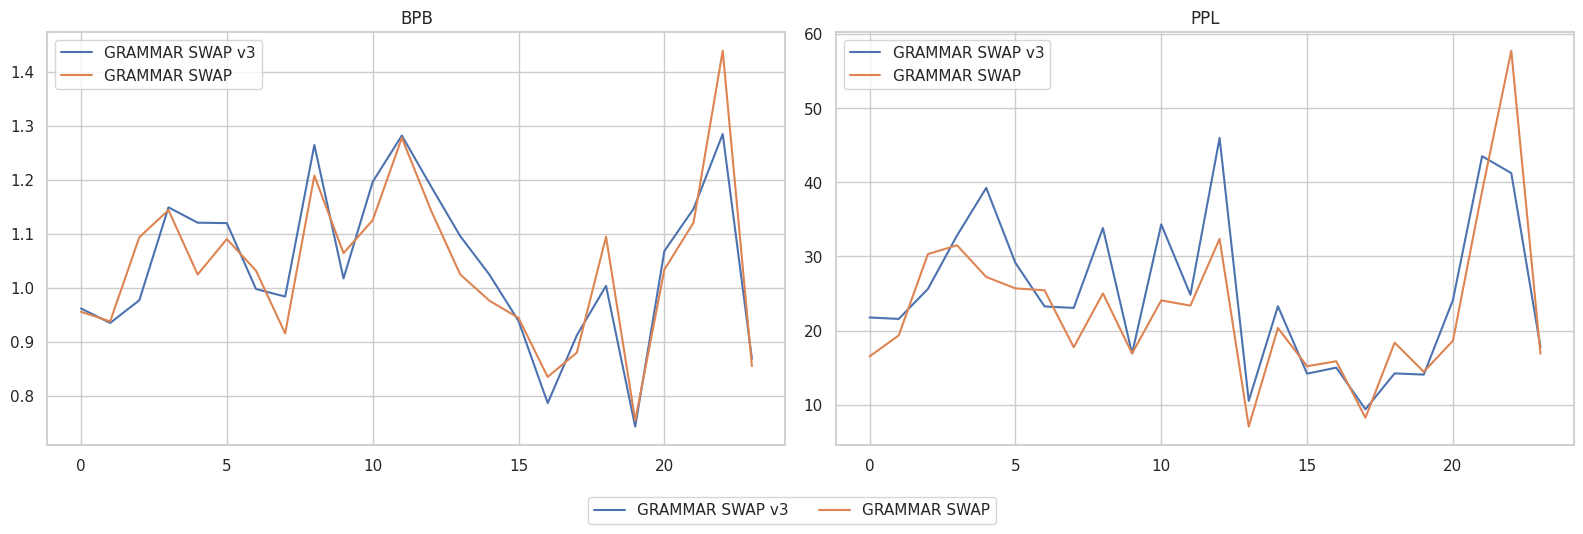

Manaca
GRAMMAR SWAP V3's BPB < GRAMMAR SWAP in 50.00% of the times
GRAMMAR SWAP V3's PPL < GRAMMAR SWAP in 33.33% of the times


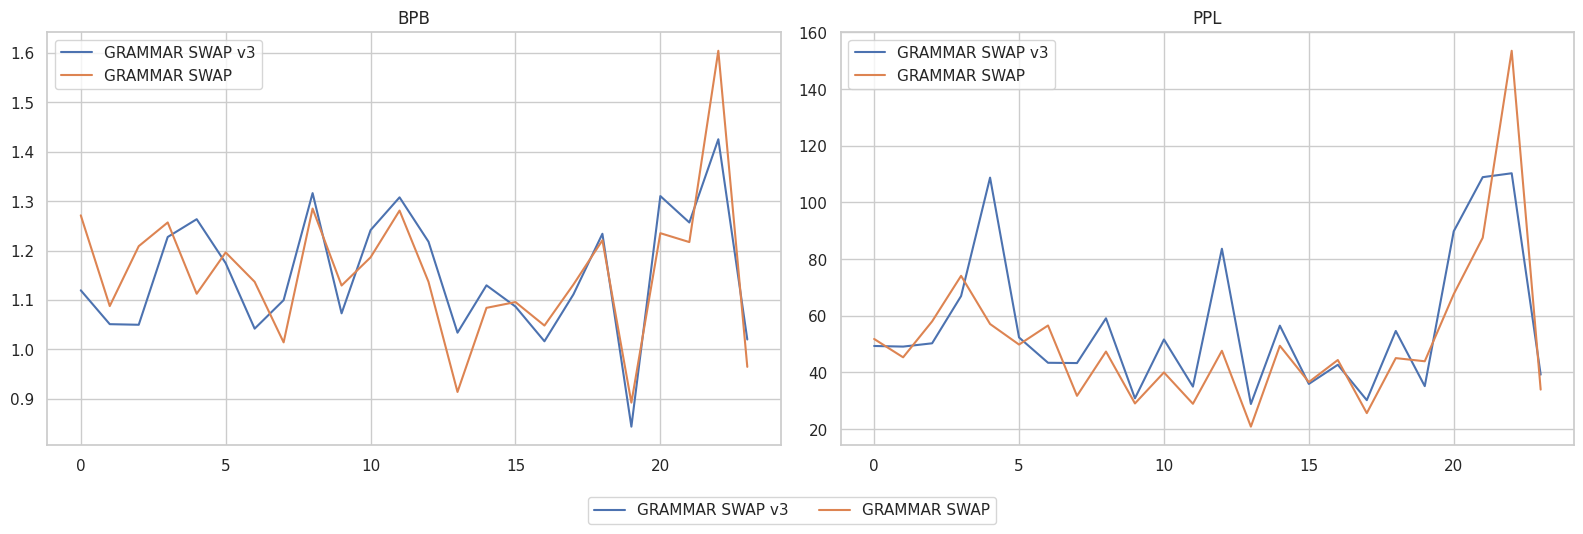

Sabia 7B
GRAMMAR SWAP V3's BPB < GRAMMAR SWAP in 45.83% of the times
GRAMMAR SWAP V3's PPL < GRAMMAR SWAP in 37.50% of the times


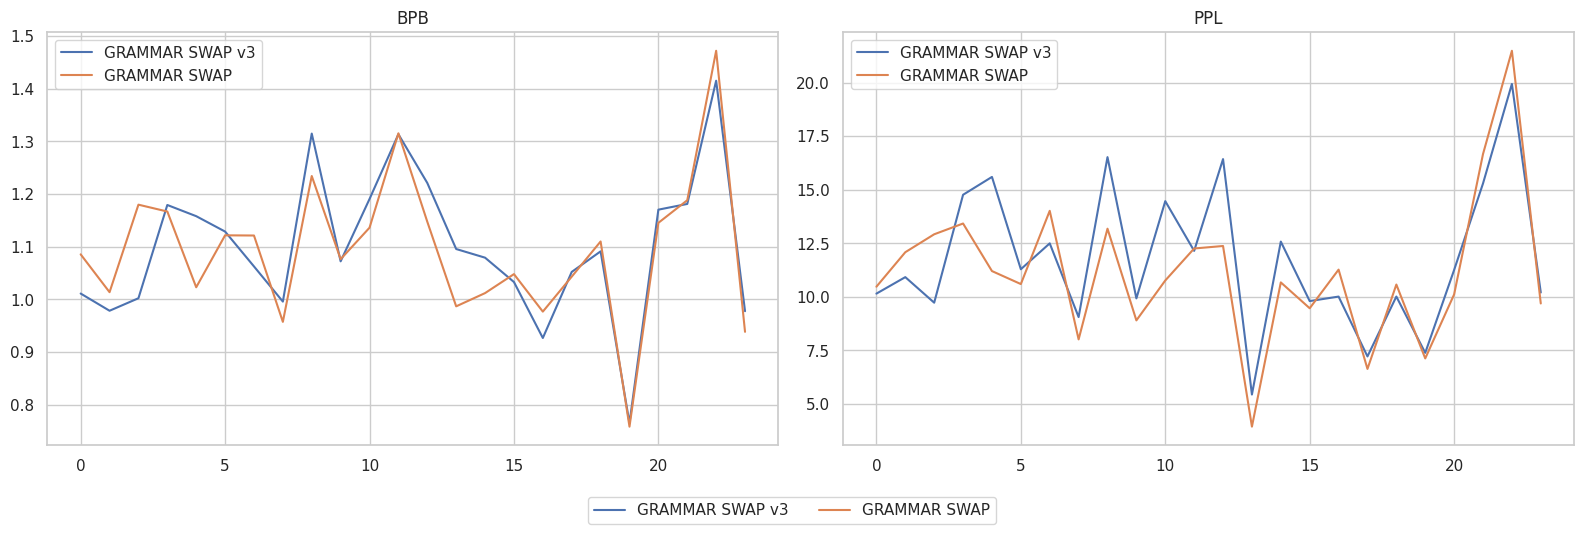

Cabrita
GRAMMAR SWAP V3's BPB < GRAMMAR SWAP in 54.17% of the times
GRAMMAR SWAP V3's PPL < GRAMMAR SWAP in 33.33% of the times


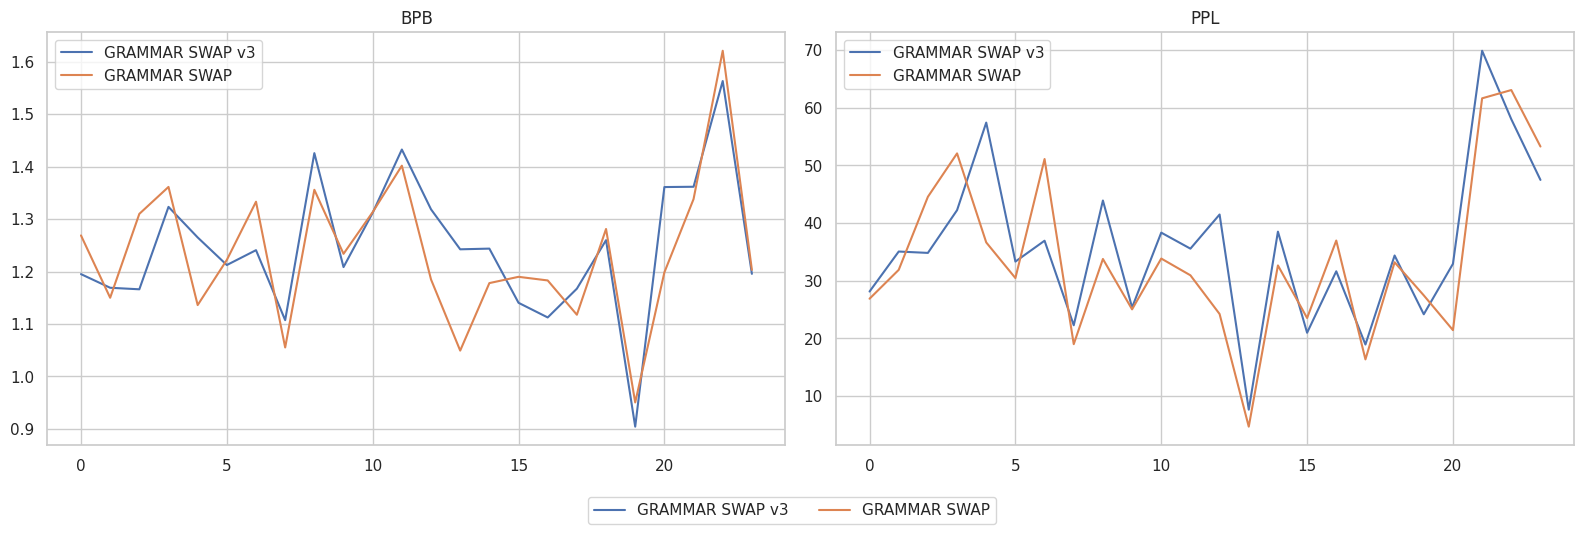

In [10]:
for model in df_res["model"].unique():
    plot_grammar_and_lexical_swap(model)